In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INDEX_CODE = "000903.SH"
START_DATE = "20160101"
END_DATE = "20260731"

csi100_stocks = get_index_stocks(
    INDEX_CODE,
    date=END_DATE
)

print("中证100成分股数量:", len(csi100_stocks))
print("前10只股票:", csi100_stocks[:10])

中证100成分股数量: 100
前10只股票: ['600436.SH', '600519.SH', '688981.SH', '600989.SH', '603019.SH', '600941.SH', '002594.SZ', '600489.SH', '002371.SZ', '000807.SZ']


In [2]:
# 完整历史研究区间
BACKTEST_START = "20160101"
BACKTEST_END = "20251231"

# 2026年留作最终独立检验
FINAL_TEST_START = "20260101"
FINAL_TEST_END = "20260731"

# 回测开始前需要2015年末的成分股名单
snapshot_dates = ["20151231"]

# 获取2016～2025年每年6月末、12月末的成分股
for year in range(2016, 2026):
    snapshot_dates.append(f"{year}0630")
    snapshot_dates.append(f"{year}1231")

snapshot_dates.append("20260630")

snapshot_dates = sorted(set(snapshot_dates))

# 获取各历史时点的中证100成分股
historical_members = {}

for date in snapshot_dates:
    members = get_index_stocks(
        INDEX_CODE,
        date=date
    )

    historical_members[date] = members

    print(
        date,
        "成分股数量:",
        len(members)
    )

# 合并历史上出现过的所有成分股
historical_stock_pool = sorted(
    set().union(*historical_members.values())
)

print("-" * 40)
print("历史快照数量:", len(historical_members))
print(
    "历史成分股并集数量:",
    len(historical_stock_pool)
)
print(
    "历史股票池前10只:",
    historical_stock_pool[:10]
)

20151231 成分股数量: 100
20160630 成分股数量: 100
20161231 成分股数量: 100
20170630 成分股数量: 100
20171231 成分股数量: 100
20180630 成分股数量: 100
20181231 成分股数量: 100
20190630 成分股数量: 100
20191231 成分股数量: 100
20200630 成分股数量: 100
20201231 成分股数量: 100
20210630 成分股数量: 100
20211231 成分股数量: 100
20220630 成分股数量: 100
20221231 成分股数量: 100
20230630 成分股数量: 100
20231231 成分股数量: 100
20240630 成分股数量: 100
20241231 成分股数量: 100
20250630 成分股数量: 100
20251231 成分股数量: 100
20260630 成分股数量: 100
----------------------------------------
历史快照数量: 22
历史成分股并集数量: 239
历史股票池前10只: ['000001.SZ', '000002.SZ', '000063.SZ', '000069.SZ', '000100.SZ', '000166.SZ', '000301.SZ', '000333.SZ', '000338.SZ', '000425.SZ']


In [3]:
# 获取历史股票池的日线行情
price_panel = get_price(
    historical_stock_pool,
    start_date=BACKTEST_START,
    end_date=BACKTEST_END,
    fre_step="1d",
    fields=[
        "close",
        "volume",
        "turnover"
    ],
    skip_paused=False,
    fq="post",
    is_panel=1
)

close_data = price_panel["close"]
volume_data = price_panel["volume"]
turnover_data = price_panel["turnover"]

print("股票池数量:", len(historical_stock_pool))
print("收盘价维度:", close_data.shape)
print("开始日期:", close_data.index.min())
print("结束日期:", close_data.index.max())
print(
    "收盘价缺失比例:",
    f"{close_data.isna().mean().mean():.2%}"
)

print("非正收盘价:", (close_data <= 0).sum().sum())
close_data.tail()

股票池数量: 239
收盘价维度: (2430, 239)
开始日期: 2016-01-04 00:00:00
结束日期: 2025-12-31 00:00:00
收盘价缺失比例: 6.01%
非正收盘价: 0


,000001.SZ,000002.SZ,000063.SZ,000069.SZ,000100.SZ,000166.SZ,000301.SZ,000333.SZ,000338.SZ,000425.SZ,...,603993.SH,688008.SH,688012.SH,688036.SH,688041.SH,688111.SH,688256.SH,688271.SH,688599.SH,688981.SH
2025-12-25,1621.76,839.58,521.52,91.49,13.44,8.35,22.60,443.28,406.24,356.37,...,69.16,125.01,274.17,109.24,221.16,307.00,1319.41,130.42,18.09,123.08
2025-12-26,1618.96,836.08,518.65,89.37,13.35,8.38,23.29,444.86,411.88,374.71,...,73.05,124.58,274.17,108.40,218.30,306.18,1303.89,131.13,18.28,122.10
2025-12-29,1621.76,830.82,512.90,88.66,13.50,8.35,23.88,442.26,406.71,375.38,...,69.83,122.77,274.17,108.63,219.93,304.49,1358.50,128.46,18.26,122.50
2025-12-30,1610.54,809.78,510.03,87.60,13.65,8.32,24.70,444.75,407.42,377.71,...,72.19,123.58,274.17,109.23,225.73,309.42,1415.80,127.90,17.86,125.28
2025-12-31,1600.72,815.04,517.83,87.60,13.65,8.30,23.66,440.80,403.66,386.04,...,73.97,121.40,274.17,106.87,225.13,311.58,1355.55,126.28,17.63,122.83


In [4]:
# 创建历史成分股掩码
membership_mask = pd.DataFrame(
    False,
    index=close_data.index,
    columns=close_data.columns
)

sorted_snapshots = sorted(
    historical_members.keys()
)

for i, snapshot_date in enumerate(sorted_snapshots):

    snapshot_time = pd.Timestamp(snapshot_date)

    # 当前快照从下一个交易日开始使用
    if i < len(sorted_snapshots) - 1:
        next_snapshot_time = pd.Timestamp(
            sorted_snapshots[i + 1]
        )

        date_mask = (
            (membership_mask.index > snapshot_time)
            & (membership_mask.index <= next_snapshot_time)
        )
    else:
        date_mask = (
            membership_mask.index > snapshot_time
        )

    # 只保留数据表中存在的股票
    valid_members = [
        stock
        for stock in historical_members[snapshot_date]
        if stock in membership_mask.columns
    ]

    membership_mask.loc[
        date_mask,
        valid_members
    ] = True

# 每日可用成分股数量
daily_member_count = membership_mask.sum(axis=1)

print("最少成分股数量:", daily_member_count.min())
print("最多成分股数量:", daily_member_count.max())
print("平均成分股数量:", daily_member_count.mean())

print("\n部分日期的成分股数量：")
print(
    daily_member_count.loc[
        [
            "2016-01-04",
            "2018-01-02",
            "2020-01-02",
            "2022-01-04",
            "2024-01-02",
            "2025-12-31"
        ]
    ]
)

最少成分股数量: 100
最多成分股数量: 100
平均成分股数量: 100.0

部分日期的成分股数量：
2016-01-04    100
2018-01-02    100
2020-01-02    100
2022-01-04    100
2024-01-02    100
2025-12-31    100
dtype: int64


In [5]:
# 测试单日基本面数据接口
fundamental_test = get_fundamentals(
    query(
        valuation.symbol,
        valuation.pe_ttm,
        valuation.pb,
        valuation.dividend_rate_12_months,
        profit.weighted_roe
    ),
    date="20251231"
)

print("返回维度:", fundamental_test.shape)
print("返回字段:")
print(fundamental_test.columns.tolist())

# 只保留当日中证100成分股
current_members = set(
    historical_members["20251231"]
)

symbol_column = "valuation_symbol"

fundamental_test = fundamental_test[
    fundamental_test[symbol_column].isin(
        current_members
    )
]

print(
    "中证100有效基本面记录数:",
    len(fundamental_test)
)

fundamental_test.head(10)

返回维度: (5407, 5)
返回字段:
['valuation_symbol', 'valuation_pe_ttm', 'valuation_pb', 'valuation_dividend_rate_12_months', 'profit_weighted_roe']
中证100有效基本面记录数: 100


,valuation_symbol,valuation_pe_ttm,valuation_pb,valuation_dividend_rate_12_months,profit_weighted_roe
15,300015.SZ,31.81,4.56,1.45,14.32
169,601600.SH,14.70,2.92,2.11,15.25
173,601088.SH,14.81,2.01,8.00,9.35
250,000002.SZ,-0.93,0.32,NaN,-14.81
373,002422.SZ,28.16,2.00,2.13,5.18
376,600426.SH,20.68,2.07,1.75,7.45
582,600150.SH,37.09,1.77,0.45,6.20
585,688041.SH,220.39,22.30,0.08,9.30
622,600900.SH,20.37,3.01,3.47,13.01
811,600160.SH,26.20,5.08,0.60,16.87


In [6]:
# 获取每个月最后一个真实交易日
month_end_dates = (
    pd.Series(
        close_data.index,
        index=close_data.index
    )
    .groupby(
        close_data.index.to_period("M")
    )
    .max()
    .tolist()
)

monthly_fundamental_list = []

for i, trade_date in enumerate(month_end_dates):

    # 获取该月末当时属于中证100的股票
    members = membership_mask.columns[
        membership_mask.loc[trade_date]
    ].tolist()

    # 只查询当时的100只成分股
    q = query(
        valuation.symbol,
        valuation.pe_ttm,
        valuation.pb,
        valuation.dividend_rate_12_months,
        profit.weighted_roe
    ).filter(
        valuation.symbol.in_(members)
    )

    monthly_data = get_fundamentals(
        q,
        date=trade_date.strftime("%Y%m%d")
    )

    monthly_data["date"] = trade_date

    monthly_fundamental_list.append(
        monthly_data
    )

    # 每12个月显示一次进度
    if (
        (i + 1) % 12 == 0
        or i == len(month_end_dates) - 1
    ):
        print(
            f"已完成 {i + 1}/"
            f"{len(month_end_dates)} 个月"
        )

# 合并所有月份
monthly_fundamentals = pd.concat(
    monthly_fundamental_list,
    ignore_index=True
)

print("-" * 40)
print(
    "月份数量:",
    monthly_fundamentals["date"].nunique()
)
print(
    "数据总行数:",
    len(monthly_fundamentals)
)
print(
    "股票数量:",
    monthly_fundamentals[
        "valuation_symbol"
    ].nunique()
)

monthly_fundamentals.tail(10)

已完成 12/120 个月
已完成 24/120 个月
已完成 36/120 个月
已完成 48/120 个月
已完成 60/120 个月
已完成 72/120 个月
已完成 84/120 个月
已完成 96/120 个月
已完成 108/120 个月
已完成 120/120 个月
----------------------------------------
月份数量: 120
数据总行数: 11992
股票数量: 226


,valuation_symbol,valuation_pe_ttm,valuation_pb,valuation_dividend_rate_12_months,profit_weighted_roe,date
11982,603799.SH,24.20,2.71,0.65,10.79,2025-12-31
11983,603986.SH,105.70,7.58,0.16,6.30,2025-12-31
11984,603993.SH,21.90,5.51,1.28,18.65,2025-12-31
11985,688008.SH,65.37,10.66,0.50,13.60,2025-12-31
11986,688012.SH,89.22,7.95,0.11,5.87,2025-12-31
11987,688041.SH,220.39,22.30,0.08,9.30,2025-12-31
11988,688111.SH,79.74,11.57,0.29,9.97,2025-12-31
11989,688256.SH,304.57,37.45,NaN,25.21,2025-12-31
11990,688271.SH,60.45,4.98,0.17,5.50,2025-12-31
11991,688981.SH,204.28,6.50,NaN,2.60,2025-12-31


In [7]:
# ==================================================
# Block 1：构建月频价格、基本面和技术因子矩阵
# ==================================================

monthly_close = close_data.reindex(
    month_end_dates
)

monthly_membership = membership_mask.reindex(
    month_end_dates
)


# 将基本面长表转换为“日期 × 股票”矩阵
def make_factor_matrix(column_name):
    return (
        monthly_fundamentals
        .pivot_table(
            index="date",
            columns="valuation_symbol",
            values=column_name,
            aggfunc="last"
        )
        .reindex(
            index=month_end_dates,
            columns=historical_stock_pool
        )
    )


# 基本面因子
pe_ttm = make_factor_matrix(
    "valuation_pe_ttm"
)

pb = make_factor_matrix(
    "valuation_pb"
)

dividend_yield = make_factor_matrix(
    "valuation_dividend_rate_12_months"
)

roe = make_factor_matrix(
    "profit_weighted_roe"
)


# PE和PB必须为正数才有正常估值含义
pe_ttm = pe_ttm.where(pe_ttm > 0)
pb = pb.where(pb > 0)


# 日收益率
daily_returns = close_data.pct_change(
    fill_method=None
)


# 20日收益率
return_20 = (
    close_data
    / close_data.shift(20)
    - 1
).reindex(month_end_dates)


# 60日收益率
return_60 = (
    close_data
    / close_data.shift(60)
    - 1
).reindex(month_end_dates)


# 120日收益率
return_120 = (
    close_data
    / close_data.shift(120)
    - 1
).reindex(month_end_dates)


# 240日收益率
return_240 = (
    close_data
    / close_data.shift(240)
    - 1
).reindex(month_end_dates)


# 年化20日波动率
volatility_20 = (
    daily_returns
    .rolling(20)
    .std()
    * np.sqrt(252)
).reindex(month_end_dates)


# 年化60日波动率
volatility_60 = (
    daily_returns
    .rolling(60)
    .std()
    * np.sqrt(252)
).reindex(month_end_dates)


# 年化120日波动率
volatility_120 = (
    daily_returns
    .rolling(120)
    .std()
    * np.sqrt(252)
).reindex(month_end_dates)


# 最近20日平均成交额
average_turnover_20 = (
    turnover_data
    .rolling(20)
    .mean()
).reindex(month_end_dates)


# 当前月末至下个月末的收益率
next_month_return = (
    monthly_close
    .pct_change(fill_method=None)
    .shift(-1)
)


# 清除可能残留的无穷值
return_20 = return_20.replace(
    [np.inf, -np.inf],
    np.nan
)

return_60 = return_60.replace(
    [np.inf, -np.inf],
    np.nan
)

return_120 = return_120.replace(
    [np.inf, -np.inf],
    np.nan
)

return_240 = return_240.replace(
    [np.inf, -np.inf],
    np.nan
)

next_month_return = next_month_return.replace(
    [np.inf, -np.inf],
    np.nan
)


# 只统计当期中证100成分股中的有效比例
pe_valid_ratio = (
    pe_ttm.notna() & monthly_membership
).sum().sum() / monthly_membership.sum().sum()

roe_valid_ratio = (
    roe.notna() & monthly_membership
).sum().sum() / monthly_membership.sum().sum()


print("月末价格矩阵:", monthly_close.shape)
print("PE矩阵:", pe_ttm.shape)
print("ROE矩阵:", roe.shape)
print("下月收益矩阵:", next_month_return.shape)
print(
    "当期成分股PE有效比例:",
    f"{pe_valid_ratio:.2%}"
)
print(
    "当期成分股ROE有效比例:",
    f"{roe_valid_ratio:.2%}"
)

月末价格矩阵: (120, 239)
PE矩阵: (120, 239)
ROE矩阵: (120, 239)
下月收益矩阵: (120, 239)
当期成分股PE有效比例: 96.47%
当期成分股ROE有效比例: 99.90%


In [8]:
# ==================================================
# Block 1.1：构建月末可交易股票掩码
# ==================================================

monthly_volume = volume_data.reindex(
    month_end_dates
)

# 最近20个交易日中实际有成交的天数比例
recent_trading_ratio = (
    (volume_data > 0)
    .rolling(20)
    .mean()
    .reindex(month_end_dates)
)

# 入选条件：
# 1. 当时属于中证100
# 2. 月末有有效收盘价
# 3. 月末当日有成交
# 4. 最近20日中至少80%的交易日有成交
eligible_mask = (
    monthly_membership
    & monthly_close.notna()
    & (monthly_volume > 0)
    & (recent_trading_ratio >= 0.8)
)

eligible_count = eligible_mask.sum(axis=1)

print(
    "每月最少可交易股票数:",
    eligible_count.min()
)
print(
    "每月最多可交易股票数:",
    eligible_count.max()
)
print(
    "每月平均可交易股票数:",
    f"{eligible_count.mean():.2f}"
)

print("\n2018年5月末可交易状态：")
print(
    "中兴通讯:",
    eligible_mask.loc[
        "2018-05-31",
        "000063.SZ"
    ]
)

每月最少可交易股票数: 90
每月最多可交易股票数: 100
每月平均可交易股票数: 98.15

2018年5月末可交易状态：
中兴通讯: False


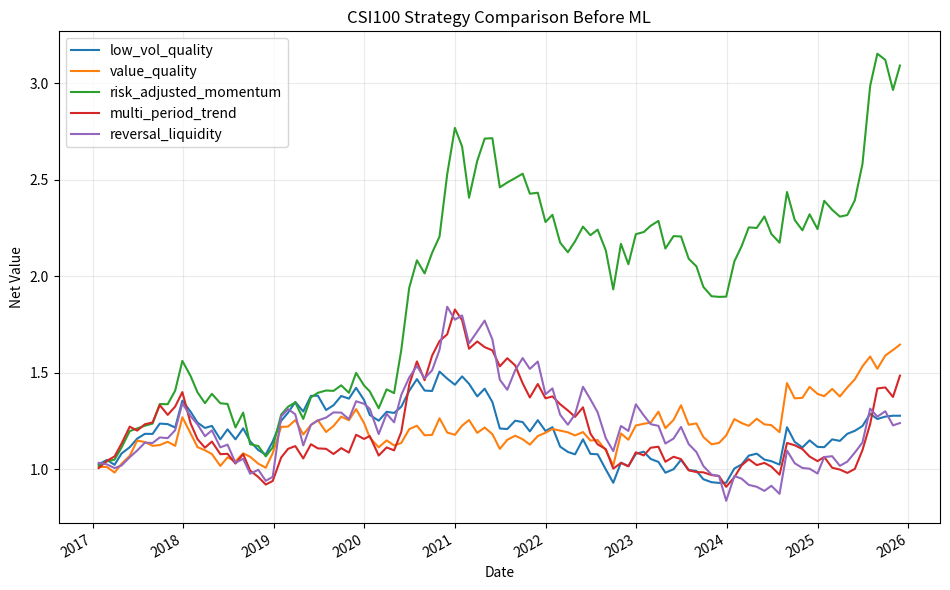

五种策略扣费后累计收益：
risk_adjusted_momentum    209.07%
value_quality              64.59%
multi_period_trend         48.52%
low_vol_quality            27.79%
reversal_liquidity         24.00%
Name: 2025-11-28 00:00:00, dtype: object

五种策略平均月度换手率：
value_quality              19.91%
low_vol_quality            47.48%
risk_adjusted_momentum     49.81%
multi_period_trend        107.38%
reversal_liquidity        122.34%
dtype: object


In [9]:
# Block 2：五种规则策略统一回测

TOP_K = 20
COST_RATE = 0.001
COMPARE_START = pd.Timestamp("2017-01-01")


def rank_high(factor):
    factor = factor.where(eligible_mask)
    factor = factor.replace(
        [np.inf, -np.inf],
        np.nan
    )

    return factor.rank(
        axis=1,
        pct=True,
        ascending=True
    )


def rank_low(factor):
    factor = factor.where(eligible_mask)
    factor = factor.replace(
        [np.inf, -np.inf],
        np.nan
    )

    return factor.rank(
        axis=1,
        pct=True,
        ascending=False
    )


def combine_scores(score_list, min_valid):
    score_array = np.stack(
        [
            score.to_numpy(dtype=float)
            for score in score_list
        ],
        axis=0
    )

    valid_count = np.isfinite(
        score_array
    ).sum(axis=0)

    score_sum = np.nansum(
        score_array,
        axis=0
    )

    combined_array = np.full(
        score_sum.shape,
        np.nan,
        dtype=float
    )

    np.divide(
        score_sum,
        valid_count,
        out=combined_array,
        where=valid_count >= min_valid
    )

    combined = pd.DataFrame(
        combined_array,
        index=monthly_close.index,
        columns=monthly_close.columns
    )

    return combined.where(eligible_mask)


def backtest_score(score, top_k=TOP_K):
    score = score.where(eligible_mask)
    score = score.replace(
        [np.inf, -np.inf],
        np.nan
    )

    cross_section_rank = score.rank(
        axis=1,
        ascending=False,
        method="first"
    )

    selected = (
        cross_section_rank <= top_k
    ).astype(float)

    weights = selected.div(
        selected.sum(axis=1),
        axis=0
    ).fillna(0)

    turnover = (
        weights.diff()
        .abs()
        .sum(axis=1)
        .fillna(0)
    )

    gross_return = (
        weights * next_month_return
    ).sum(
        axis=1,
        min_count=1
    )

    trading_cost = turnover * COST_RATE
    net_return = gross_return - trading_cost

    gross_return = gross_return.replace(
        [np.inf, -np.inf],
        np.nan
    )

    net_return = net_return.replace(
        [np.inf, -np.inf],
        np.nan
    )

    valid_period = (
        net_return.index >= COMPARE_START
    )

    net_return = net_return[
        valid_period
    ].dropna()

    gross_return = gross_return.reindex(
        net_return.index
    )

    turnover = turnover.reindex(
        net_return.index
    )

    trading_cost = trading_cost.reindex(
        net_return.index
    )

    net_value = (
        1 + net_return
    ).cumprod()

    return {
        "weights": weights,
        "gross_return": gross_return,
        "net_return": net_return,
        "turnover": turnover,
        "trading_cost": trading_cost,
        "net_value": net_value
    }


# 1. 低波动 + 质量
score_low_vol_quality = combine_scores(
    [
        rank_low(volatility_60),
        rank_high(roe)
    ],
    min_valid=2
)


# 2. 价值 + 质量
score_value_quality = combine_scores(
    [
        rank_low(pe_ttm),
        rank_low(pb),
        rank_high(dividend_yield),
        rank_high(roe)
    ],
    min_valid=3
)


# 3. 风险调整动量
momentum_12_1 = (
    close_data.shift(20)
    / close_data.shift(240)
    - 1
).reindex(month_end_dates)

risk_adjusted_momentum = (
    momentum_12_1
    / volatility_120
).replace(
    [np.inf, -np.inf],
    np.nan
)

score_risk_adjusted_momentum = rank_high(
    risk_adjusted_momentum
)


# 4. 多周期趋势
score_multi_period_trend = combine_scores(
    [
        rank_high(return_20),
        rank_high(return_60),
        rank_high(return_120)
    ],
    min_valid=3
)


# 5. 短期反转 + 流动性
score_reversal_liquidity = combine_scores(
    [
        rank_low(return_20),
        rank_high(average_turnover_20)
    ],
    min_valid=2
)


strategy_results = {
    "low_vol_quality": backtest_score(
        score_low_vol_quality
    ),
    "value_quality": backtest_score(
        score_value_quality
    ),
    "risk_adjusted_momentum": backtest_score(
        score_risk_adjusted_momentum
    ),
    "multi_period_trend": backtest_score(
        score_multi_period_trend
    ),
    "reversal_liquidity": backtest_score(
        score_reversal_liquidity
    )
}


strategy_values = pd.DataFrame({
    name: result["net_value"]
    for name, result in strategy_results.items()
})


strategy_values.plot(
    figsize=(9.6, 6),
    title="CSI100 Strategy Comparison Before ML"
)

plt.xlabel("Date")
plt.ylabel("Net Value")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


summary_return = (
    strategy_values.iloc[-1] - 1
).sort_values(
    ascending=False
)

print("五种策略扣费后累计收益：")
print(
    summary_return.apply(
        lambda value: f"{value:.2%}"
    )
)


average_turnover = pd.Series({
    name: result["turnover"].mean()
    for name, result in strategy_results.items()
}).sort_values()

print("\n五种策略平均月度换手率：")
print(
    average_turnover.apply(
        lambda value: f"{value:.2%}"
    )
)

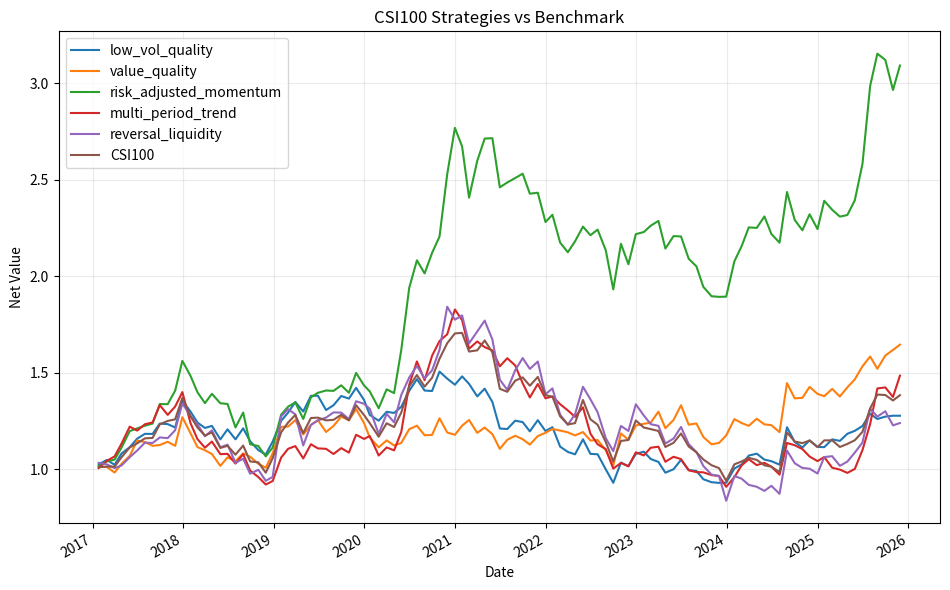

,累计收益,年化收益,年化波动,Sharpe,最大回撤,Calmar,月胜率,平均月换手
risk_adjusted_momentum,209.07%,13.49%,20.95%,0.71,-31.65%,0.43,57.01%,49.81%
value_quality,64.59%,5.75%,16.83%,0.41,-22.26%,0.26,53.27%,19.91%
multi_period_trend,48.52%,4.54%,19.90%,0.32,-50.23%,0.09,47.66%,107.38%
CSI100,38.42%,3.71%,18.07%,0.29,-44.87%,0.08,53.27%,
low_vol_quality,27.79%,2.79%,16.07%,0.25,-38.25%,0.07,46.73%,47.48%
reversal_liquidity,24.00%,2.44%,25.16%,0.21,-54.52%,0.04,47.66%,122.34%


In [10]:
# Block 5：基准与风险指标

benchmark_data = get_price(
    INDEX_CODE,
    start_date=BACKTEST_START,
    end_date=BACKTEST_END,
    fre_step="1d",
    fields=["close"],
    skip_paused=False,
    fq="post"
)

benchmark_close = (
    benchmark_data["close"]
    .squeeze()
    .reindex(close_data.index)
)

benchmark_monthly_close = benchmark_close.reindex(
    month_end_dates
)

benchmark_return = (
    benchmark_monthly_close
    .pct_change(fill_method=None)
    .shift(-1)
)

comparison_index = strategy_results[
    "risk_adjusted_momentum"
]["net_return"].index

benchmark_return = benchmark_return.reindex(
    comparison_index
).dropna()

comparison_returns = pd.DataFrame({
    name: result["net_return"].reindex(
        benchmark_return.index
    )
    for name, result in strategy_results.items()
})

comparison_returns["CSI100"] = benchmark_return

comparison_returns = comparison_returns.dropna()

comparison_values = (
    1 + comparison_returns
).cumprod()


def calculate_metrics(
    monthly_return,
    turnover=None
):
    monthly_return = monthly_return.dropna()
    periods = len(monthly_return)

    total_return = (
        1 + monthly_return
    ).prod() - 1

    annual_return = (
        (1 + total_return) ** (
            12 / periods
        )
        - 1
    )

    annual_volatility = (
        monthly_return.std()
        * np.sqrt(12)
    )

    if monthly_return.std() > 0:
        sharpe = (
            monthly_return.mean()
            / monthly_return.std()
            * np.sqrt(12)
        )
    else:
        sharpe = np.nan

    net_value = (
        1 + monthly_return
    ).cumprod()

    drawdown = (
        net_value
        / net_value.cummax()
        - 1
    )

    max_drawdown = drawdown.min()

    if max_drawdown < 0:
        calmar = (
            annual_return
            / abs(max_drawdown)
        )
    else:
        calmar = np.nan

    win_rate = (
        monthly_return > 0
    ).mean()

    if turnover is not None:
        average_turnover = (
            turnover
            .reindex(monthly_return.index)
            .mean()
        )
    else:
        average_turnover = np.nan

    return {
        "累计收益": total_return,
        "年化收益": annual_return,
        "年化波动": annual_volatility,
        "Sharpe": sharpe,
        "最大回撤": max_drawdown,
        "Calmar": calmar,
        "月胜率": win_rate,
        "平均月换手": average_turnover
    }


metrics = {}

for name, result in strategy_results.items():
    metrics[name] = calculate_metrics(
        comparison_returns[name],
        result["turnover"]
    )

metrics["CSI100"] = calculate_metrics(
    comparison_returns["CSI100"]
)

metrics_table = pd.DataFrame(
    metrics
).T

metrics_table = metrics_table.sort_values(
    "Sharpe",
    ascending=False
)


comparison_values.plot(
    figsize=(9.6, 6),
    title="CSI100 Strategies vs Benchmark"
)

plt.xlabel("Date")
plt.ylabel("Net Value")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


display_table = metrics_table.copy()

percent_columns = [
    "累计收益",
    "年化收益",
    "年化波动",
    "最大回撤",
    "月胜率",
    "平均月换手"
]

for column in percent_columns:
    display_table[column] = (
        display_table[column]
        .map(
            lambda value: (
                ""
                if pd.isna(value)
                else f"{value:.2%}"
            )
        )
    )

display_table["Sharpe"] = (
    display_table["Sharpe"]
    .map(
        lambda value: f"{value:.2f}"
    )
)

display_table["Calmar"] = (
    display_table["Calmar"]
    .map(
        lambda value: f"{value:.2f}"
    )
)

display_table

训练样本数: 3475
测试样本数: 7174
测试月份数: 72


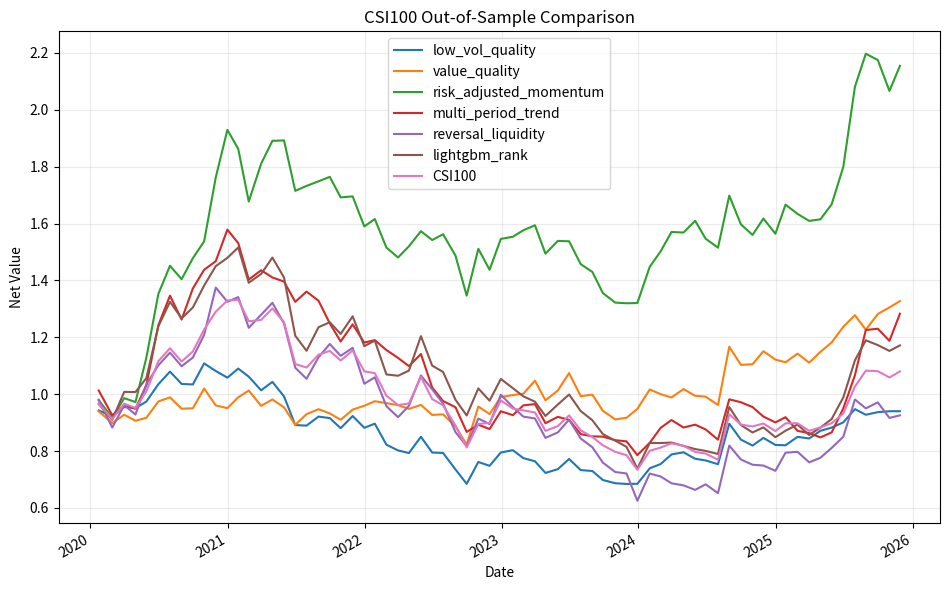

2020年以来累计收益：
risk_adjusted_momentum    115.46%
value_quality              32.75%
multi_period_trend         28.29%
lightgbm_rank              17.16%
CSI100                      8.02%
low_vol_quality            -5.99%
reversal_liquidity         -7.44%
Name: 2025-11-28 00:00:00, dtype: object

LightGBM特征重要性：
risk_adjusted_momentum    51
low_pb                    40
roe                       40
low_pe                    37
low_volatility_60         35
dividend                  32
momentum_120              31
momentum_20               26
liquidity                 24
momentum_60               23
dtype: int32


,累计收益,年化收益,年化波动,Sharpe,最大回撤,Calmar,月胜率,平均月换手
risk_adjusted_momentum,115.46%,13.85%,21.63%,0.71,-31.60%,0.44,54.93%,49.30%
value_quality,32.75%,4.90%,16.99%,0.36,-19.34%,0.25,54.93%,20.99%
multi_period_trend,28.29%,4.30%,20.85%,0.30,-50.23%,0.09,43.66%,107.18%
lightgbm_rank,17.16%,2.71%,22.64%,0.23,-51.31%,0.05,46.48%,66.90%
CSI100,8.02%,1.31%,18.86%,0.16,-44.87%,0.03,47.89%,
reversal_liquidity,-7.44%,-1.30%,25.25%,0.07,-54.52%,-0.02,43.66%,120.14%
low_vol_quality,-5.99%,-1.04%,16.46%,0.02,-38.25%,-0.03,42.25%,47.46%


In [11]:
# Block 6：快速版LightGBM样本外排序

import gc
from lightgbm import LGBMRegressor

gc.collect()

ML_TRAIN_START = pd.Timestamp("2017-01-01")
ML_TRAIN_END = pd.Timestamp("2019-12-31")
ML_TEST_START = pd.Timestamp("2020-01-01")

feature_matrices = {
    "momentum_20": rank_high(return_20),
    "momentum_60": rank_high(return_60),
    "momentum_120": rank_high(return_120),
    "risk_adjusted_momentum": rank_high(
        risk_adjusted_momentum
    ),
    "low_volatility_60": rank_low(
        volatility_60
    ),
    "low_pe": rank_low(pe_ttm),
    "low_pb": rank_low(pb),
    "dividend": rank_high(dividend_yield),
    "roe": rank_high(roe),
    "liquidity": rank_high(
        average_turnover_20
    )
}

feature_columns = list(
    feature_matrices.keys()
)

target_rank = (
    next_month_return
    .where(eligible_mask)
    .rank(
        axis=1,
        pct=True
    )
)

dataset_parts = []

for date in month_end_dates:
    date_data = pd.DataFrame({
        name: matrix.loc[date]
        for name, matrix
        in feature_matrices.items()
    })

    date_data["target"] = target_rank.loc[
        date
    ]

    date_data["eligible"] = eligible_mask.loc[
        date
    ]

    date_data["date"] = date
    date_data["stock"] = date_data.index

    date_data = date_data[
        date_data["eligible"]
    ]

    dataset_parts.append(
        date_data.reset_index(drop=True)
    )

ml_dataset = pd.concat(
    dataset_parts,
    ignore_index=True
)

ml_dataset = ml_dataset.replace(
    [np.inf, -np.inf],
    np.nan
)

valid_feature_count = (
    ml_dataset[feature_columns]
    .notna()
    .sum(axis=1)
)

ml_dataset = ml_dataset[
    valid_feature_count >= 5
].copy()

train_data = ml_dataset[
    (
        ml_dataset["date"]
        >= ML_TRAIN_START
    )
    & (
        ml_dataset["date"]
        <= ML_TRAIN_END
    )
    & (
        ml_dataset["target"].notna()
    )
].copy()

test_data = ml_dataset[
    ml_dataset["date"]
    >= ML_TEST_START
].copy()

print("训练样本数:", len(train_data))
print("测试样本数:", len(test_data))
print(
    "测试月份数:",
    test_data["date"].nunique()
)

model = LGBMRegressor(
    objective="regression",
    n_estimators=60,
    learning_rate=0.05,
    num_leaves=7,
    max_depth=3,
    min_child_samples=50,
    colsample_bytree=0.8,
    reg_alpha=0.2,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=1,
    verbosity=-1
)

model.fit(
    train_data[feature_columns],
    train_data["target"]
)

test_data["prediction"] = model.predict(
    test_data[feature_columns]
)

prediction_score = (
    test_data
    .pivot_table(
        index="date",
        columns="stock",
        values="prediction",
        aggfunc="last"
    )
    .reindex(
        index=monthly_close.index,
        columns=monthly_close.columns
    )
)

ml_result = backtest_score(
    prediction_score
)

ml_net_return = (
    ml_result["net_return"]
    .loc[
        lambda series:
        series.index >= ML_TEST_START
    ]
)

ml_result["net_return"] = ml_net_return

ml_result["gross_return"] = (
    ml_result["gross_return"]
    .reindex(ml_net_return.index)
)

ml_result["turnover"] = (
    ml_result["turnover"]
    .reindex(ml_net_return.index)
)

ml_result["trading_cost"] = (
    ml_result["trading_cost"]
    .reindex(ml_net_return.index)
)

ml_result["net_value"] = (
    1 + ml_net_return
).cumprod()

all_strategy_results = {
    **strategy_results,
    "lightgbm_rank": ml_result
}

ml_comparison_returns = pd.DataFrame({
    name: result["net_return"]
    for name, result
    in all_strategy_results.items()
})

ml_comparison_returns = ml_comparison_returns[
    ml_comparison_returns.index >= ML_TEST_START
]

ml_comparison_returns["CSI100"] = (
    benchmark_return.reindex(ml_comparison_returns.index)
)

ml_comparison_returns = ml_comparison_returns.dropna()

ml_comparison_values = (
    1 + ml_comparison_returns
).cumprod()

ml_comparison_values.plot(
    figsize=(9.6, 6),
    title="CSI100 Out-of-Sample Comparison"
)

plt.xlabel("Date")
plt.ylabel("Net Value")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

ml_summary = (
    ml_comparison_values.iloc[-1]
    - 1
).sort_values(
    ascending=False
)

print("2020年以来累计收益：")
print(
    ml_summary.apply(
        lambda value: f"{value:.2%}"
    )
)

feature_importance = pd.Series(
    model.feature_importances_,
    index=feature_columns
).sort_values(
    ascending=False
)

print("\nLightGBM特征重要性：")
print(feature_importance)

ml_metrics = {}

for name in ml_comparison_returns.columns:
    turnover = None
    if name in all_strategy_results:
        turnover = all_strategy_results[name]["turnover"]

    ml_metrics[name] = calculate_metrics(
        ml_comparison_returns[name],
        turnover
    )

ml_metrics_table = pd.DataFrame(ml_metrics).T
ml_metrics_table = ml_metrics_table.sort_values(
    "Sharpe",
    ascending=False
)

ml_display = ml_metrics_table.copy()

for column in [
    "累计收益",
    "年化收益",
    "年化波动",
    "最大回撤",
    "月胜率",
    "平均月换手"
]:
    ml_display[column] = ml_display[column].map(
        lambda value: "" if pd.isna(value) else f"{value:.2%}"
    )

ml_display["Sharpe"] = ml_display["Sharpe"].map(
    lambda value: f"{value:.2f}"
)
ml_display["Calmar"] = ml_display["Calmar"].map(
    lambda value: f"{value:.2f}"
)

display(ml_display)

del dataset_parts
_ = gc.collect()

In [13]:
# Block 7：2026最终独立检验

FINAL_SIGNAL_START = pd.Timestamp("2025-12-01")
FINAL_SIGNAL_END = pd.Timestamp("2026-06-30")

final_returns = pd.DataFrame({
    name: result["net_return"]
    for name, result in all_strategy_results.items()
})

final_returns["CSI100"] = benchmark_return.reindex(
    final_returns.index
)

final_returns = final_returns[
    (
        final_returns.index
        >= FINAL_SIGNAL_START
    )
    & (
        final_returns.index
        <= FINAL_SIGNAL_END
    )
]

final_returns = final_returns.dropna(
    axis=1,
    how="all"
).dropna(
    axis=0,
    how="all"
)

print("各策略有效月份数:")
print(
    final_returns.notna().sum()
)

if final_returns.empty:
    raise ValueError(
        "2026最终测试没有有效收益，"
        "请确认行情已更新至2026-07-31"
    )

final_values = (
    1 + final_returns
).cumprod()

final_values.plot(
    figsize=(9.6, 6),
    title="CSI100 Final Test: Jan-Jul 2026"
)

plt.xlabel("Signal Date")
plt.ylabel("Net Value")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

final_metrics = {}

for name in final_returns.columns:
    valid_return = final_returns[
        name
    ].dropna()

    if len(valid_return) == 0:
        continue

    turnover = None

    if name in all_strategy_results:
        turnover = all_strategy_results[
            name
        ]["turnover"]

    final_metrics[name] = calculate_metrics(
        valid_return,
        turnover
    )

final_metrics_table = pd.DataFrame(
    final_metrics
).T.sort_values(
    "累计收益",
    ascending=False
)

final_display = final_metrics_table.copy()

percent_columns = [
    "累计收益",
    "年化收益",
    "年化波动",
    "最大回撤",
    "月胜率",
    "平均月换手"
]

for column in percent_columns:
    final_display[column] = (
        final_display[column].map(
            lambda value: (
                ""
                if pd.isna(value)
                else f"{value:.2%}"
            )
        )
    )

final_display["Sharpe"] = (
    final_display["Sharpe"].map(
        lambda value: f"{value:.2f}"
    )
)

final_display["Calmar"] = (
    final_display["Calmar"].map(
        lambda value: f"{value:.2f}"
    )
)

print(
    "最终测试覆盖月份:",
    len(final_returns)
)

display(final_display)

各策略有效月份数:
Series([], dtype: float64)


ValueError: 2026最终测试没有有效收益，请确认行情已更新至2026-07-31